<a href="https://colab.research.google.com/github/Nikita1532001/real-time-project/blob/main/PMPML_Bus_Data_Science_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Smart PMPML Bus Analytics & Prediction System

## Project Overview
This Data Science project analyzes Pune PMPML bus transportation data and predicts bus delays using Machine Learning.

### Features
- Bus Delay Prediction
- Passenger Trend Analysis
- Route Performance Analytics
- Data Visualization
- Machine Learning Model
- Dashboard Ready Structure


In [1]:

# Install Required Libraries (Run if needed)

# !pip install pandas numpy matplotlib seaborn scikit-learn


In [2]:

# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder



# Create PMPML Dataset


In [3]:

# Sample PMPML Dataset

data = {
    'Bus_ID':[101,102,103,104,105,106,107,108,109,110],
    'Route_No':[25,50,70,88,92,12,41,35,67,90],
    'Distance_KM':[18,12,22,15,20,11,17,13,25,16],
    'Delay_Minutes':[10,5,15,7,18,4,9,6,20,8],
    'Passenger_Count':[120,90,150,100,170,80,110,95,200,105],
    'Weather':['Rainy','Sunny','Cloudy','Sunny','Rainy',
               'Sunny','Cloudy','Sunny','Rainy','Cloudy'],
    'Traffic_Level':['High','Medium','High','Low','High',
                     'Low','Medium','Low','High','Medium']
}

df = pd.DataFrame(data)

df


,Bus_ID,Route_No,Distance_KM,Delay_Minutes,Passenger_Count,Weather,Traffic_Level
0,101,25,18,10,120,Rainy,High
1,102,50,12,5,90,Sunny,Medium
2,103,70,22,15,150,Cloudy,High
3,104,88,15,7,100,Sunny,Low
4,105,92,20,18,170,Rainy,High
5,106,12,11,4,80,Sunny,Low
6,107,41,17,9,110,Cloudy,Medium
7,108,35,13,6,95,Sunny,Low
8,109,67,25,20,200,Rainy,High
9,110,90,16,8,105,Cloudy,Medium



# Data Preprocessing


In [4]:

# Encode Categorical Data

le_weather = LabelEncoder()
le_traffic = LabelEncoder()

df['Weather'] = le_weather.fit_transform(df['Weather'])
df['Traffic_Level'] = le_traffic.fit_transform(df['Traffic_Level'])

df


,Bus_ID,Route_No,Distance_KM,Delay_Minutes,Passenger_Count,Weather,Traffic_Level
0,101,25,18,10,120,1,0
1,102,50,12,5,90,2,2
2,103,70,22,15,150,0,0
3,104,88,15,7,100,2,1
4,105,92,20,18,170,1,0
5,106,12,11,4,80,2,1
6,107,41,17,9,110,0,2
7,108,35,13,6,95,2,1
8,109,67,25,20,200,1,0
9,110,90,16,8,105,0,2



# Data Visualization


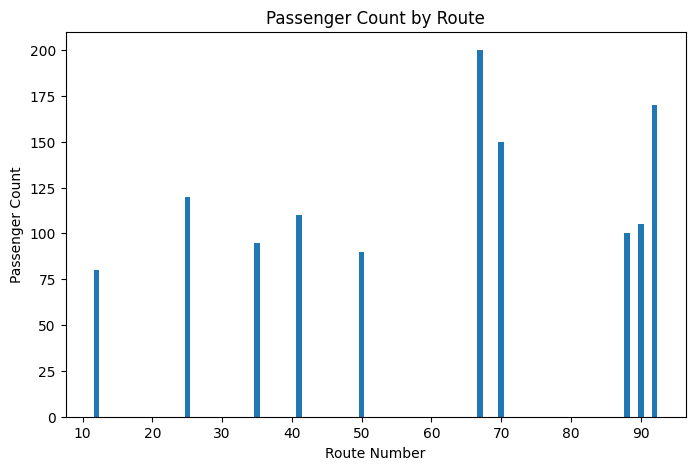

In [5]:

# Passenger Count Analysis

plt.figure(figsize=(8,5))
plt.bar(df['Route_No'], df['Passenger_Count'])
plt.xlabel("Route Number")
plt.ylabel("Passenger Count")
plt.title("Passenger Count by Route")
plt.show()


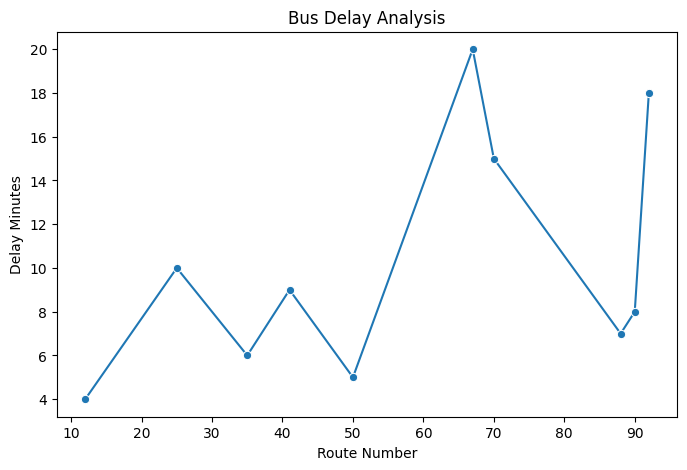

In [6]:

# Delay Analysis

plt.figure(figsize=(8,5))
sns.lineplot(x=df['Route_No'], y=df['Delay_Minutes'], marker='o')
plt.title("Bus Delay Analysis")
plt.xlabel("Route Number")
plt.ylabel("Delay Minutes")
plt.show()



# Machine Learning Model


In [7]:

# Features and Target

X = df[['Distance_KM','Passenger_Count','Weather','Traffic_Level']]
y = df['Delay_Minutes']

# Split Dataset

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Model

model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

# Predictions

predictions = model.predict(X_test)

# Evaluation

print("Mean Absolute Error:", mean_absolute_error(y_test, predictions))
print("R2 Score:", r2_score(y_test, predictions))


Mean Absolute Error: 2.195
R2 Score: 0.8435902222222222



# Predict New Bus Delay


In [8]:

# Example Prediction

new_data = pd.DataFrame({
    'Distance_KM':[19],
    'Passenger_Count':[130],
    'Weather':[2],         # Rainy
    'Traffic_Level':[0]    # High
})

prediction = model.predict(new_data)

print("Predicted Delay (Minutes):", prediction[0])


Predicted Delay (Minutes): 10.45



# Save Machine Learning Model


In [9]:

import pickle

pickle.dump(model, open('bus_prediction_model.pkl', 'wb'))

print("Model Saved Successfully!")


Model Saved Successfully!



# Project Conclusion

This project successfully:
- Analyzed PMPML bus transportation data
- Predicted bus delays using Machine Learning
- Visualized passenger and route analytics
- Demonstrated real-world Data Science workflow

## Future Enhancements
- Live GPS Tracking
- Real-time Bus Prediction
- Google Maps Integration
- Streamlit Dashboard
- Deep Learning Models
